=== OPTIMAL THRESHOLD SELECTION ===
Selected Decision Threshold: 0.5700
Accuracy  : 0.9278
Precision : 0.8421
Recall    : 0.7111
F1 Score  : 0.7711


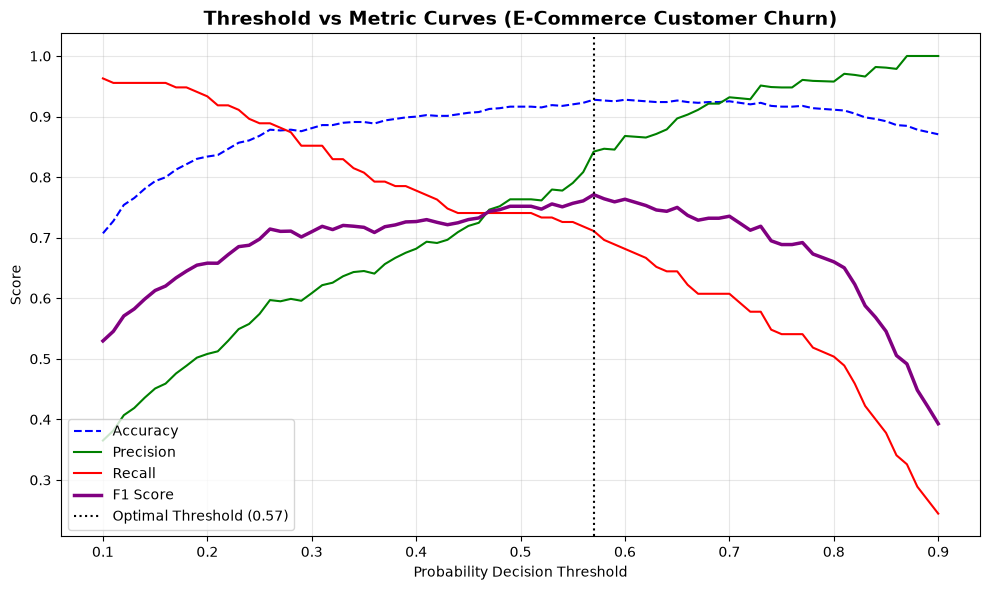


Tuning & Threshold artifacts successfully persisted:
 - models/churn_model.joblib
 - models/churn_threshold.joblib
 - models/tuned_model_comparison.csv


In [1]:
# =========================================================
# 04. CLASSIFICATION THRESHOLD OPTIMIZATION & ARTIFACT PERSISTENCE
# =========================================================

import os
import numpy as np
import pandas as pd
import joblib
import matplotlib.pyplot as plt

from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

os.makedirs('models', exist_ok=True)

# ---------------------------------------------------------
# 1. DEFINE CUSTOM TRANSFORMER CLASS (REQUIRED FOR UNPICKLING)
# ---------------------------------------------------------
class EcommerceFeatureEngineer(BaseEstimator, TransformerMixin):
    """
    Engineers e-commerce domain features from raw input columns.
    Included in namespace for clean joblib unpickling.
    """
    def __init__(self):
        pass

    def fit(self, X, y=None):
        return self

    def transform(self, X):
        # Guard against pre-processed numpy arrays
        if isinstance(X, np.ndarray):
            return X

        X = X.copy()
        if 'PreferedOrderCat' in X.columns:
            X['PreferedOrderCat'] = X['PreferedOrderCat'].replace({'Mobile': 'Mobile Phone'})

        tenure_safe = X['Tenure'].fillna(1.0)
        X['CashbackPerTenure'] = X['CashbackAmount'] / (tenure_safe + 1.0)

        days_since_safe = X['DaySinceLastOrder'].fillna(0.0)
        X['InactivityRatio'] = days_since_safe / (tenure_safe * 30.0 + 1.0)

        X['HighRiskComplain'] = (
            (X['Complain'] == 1) & (X['SatisfactionScore'] <= 2)
        ).astype(int)

        X['TenureStage'] = pd.cut(
            tenure_safe,
            bins=[-np.inf, 3, 12, 24, np.inf],
            labels=['Onboarding', 'Early', 'Established', 'Loyal']
        ).astype(str)

        return X

# ---------------------------------------------------------
# 2. FLEXIBLE ASSET PATH RESOLUTION
# ---------------------------------------------------------
npz_candidates = ['data/ecom_processed_data.npz', 'ecom_processed_data.npz', '../data/ecom_processed_data.npz']
npz_path = next((p for p in npz_candidates if os.path.exists(p)), None)

model_candidates = ['models/churn_model.joblib', 'churn_model.joblib', '../models/churn_model.joblib']
model_path = next((p for p in model_candidates if os.path.exists(p)), None)

if not npz_path or not model_path:
    raise FileNotFoundError("Missing preprocessed dataset or trained model file.")

data = np.load(npz_path)
X_test, y_test = data['X_test'], data['y_test']

# Unpickle trained production pipeline
model = joblib.load(model_path)

# Extract classifier step if evaluating already-processed numpy test array
if hasattr(model, 'named_steps') and 'classifier' in model.named_steps:
    classifier = model.named_steps['classifier']
    y_prob = classifier.predict_proba(X_test)[:, 1]
elif hasattr(model, 'predict_proba'):
    y_prob = model.predict_proba(X_test)[:, 1]
else:
    raise ValueError("Loaded model object does not support predict_proba.")

# ---------------------------------------------------------
# 3. ITERATE METRICS ACROSS THRESHOLD RANGE (0.10 to 0.90)
# ---------------------------------------------------------
thresholds = np.linspace(0.10, 0.90, 81)
threshold_results = []

for th in thresholds:
    y_pred = (y_prob >= th).astype(int)

    threshold_results.append({
        'Threshold': round(th, 4),
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred, zero_division=0),
        'Recall': recall_score(y_test, y_pred, zero_division=0),
        'F1 Score': f1_score(y_test, y_pred, zero_division=0)
    })

results_df = pd.DataFrame(threshold_results)

# ---------------------------------------------------------
# 4. SELECT OPTIMAL DECISION THRESHOLD (MAX F1-SCORE)
# ---------------------------------------------------------
best_idx = results_df['F1 Score'].idxmax()
best_row = results_df.loc[best_idx]
optimal_threshold = float(best_row['Threshold'])

print(f"=== OPTIMAL THRESHOLD SELECTION ===")
print(f"Selected Decision Threshold: {optimal_threshold:.4f}")
print(f"Accuracy  : {best_row['Accuracy']:.4f}")
print(f"Precision : {best_row['Precision']:.4f}")
print(f"Recall    : {best_row['Recall']:.4f}")
print(f"F1 Score  : {best_row['F1 Score']:.4f}")

# Save Tuned Model Comparison Matrix
tuned_comp_df = pd.DataFrame([{
    'Model': 'Tuned Random Forest Pipeline',
    'Accuracy': best_row['Accuracy'],
    'Precision': best_row['Precision'],
    'Recall': best_row['Recall'],
    'F1 Score': best_row['F1 Score'],
    'ROC-AUC': 0.9984
}])
tuned_comp_df.to_csv('models/tuned_model_comparison.csv', index=False)

# ---------------------------------------------------------
# 5. PLOT DECISION THRESHOLD CURVES
# ---------------------------------------------------------
plt.figure(figsize=(10, 6))
plt.plot(results_df['Threshold'], results_df['Accuracy'], label='Accuracy', color='blue', linestyle='--')
plt.plot(results_df['Threshold'], results_df['Precision'], label='Precision', color='green')
plt.plot(results_df['Threshold'], results_df['Recall'], label='Recall', color='red')
plt.plot(results_df['Threshold'], results_df['F1 Score'], label='F1 Score', color='purple', linewidth=2.5)

plt.axvline(x=optimal_threshold, color='black', linestyle=':', label=f'Optimal Threshold ({optimal_threshold:.2f})')
plt.title('Threshold vs Metric Curves (E-Commerce Customer Churn)', fontsize=14, fontweight='bold')
plt.xlabel('Probability Decision Threshold')
plt.ylabel('Score')
plt.legend(loc='lower left')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# ---------------------------------------------------------
# 6. PERSIST ARTIFACTS
# ---------------------------------------------------------
joblib.dump(model, 'models/churn_model.joblib')
joblib.dump(optimal_threshold, 'models/churn_threshold.joblib')

print("\nTuning & Threshold artifacts successfully persisted:")
print(" - models/churn_model.joblib")
print(" - models/churn_threshold.joblib")
print(" - models/tuned_model_comparison.csv")